In [2]:
import IPython
import numpy as np
import tvm
from tvm import relax
from tvm.ir.module import IRModule
from tvm.script import relax as R
from tvm.script import tirx as T

import torch
import torchvision

In [3]:
test_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor()
)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=True)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

img, label = next(iter(test_loader))
img = img.reshape(1, 28, 28).numpy()

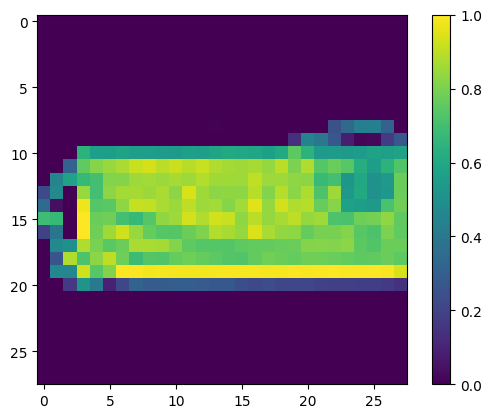

Class: Bag


In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(img[0])
plt.colorbar()
plt.grid(False)
plt.show()
print("Class:", class_names[label[0]])

In [5]:
def numpy_mlp(data, w0, b0, w1, b1):
    lv0 = data @ w0.T + b0
    lv1 = np.maximum(lv0, 0)
    lv2 = lv1 @ w1.T + b1
    return lv2

import pickle as pkl

mlp_params = pkl.load(open("fasionmnist_mlp_params.pkl", "rb"))

res = numpy_mlp(img.reshape(1, 784),
                mlp_params["w0"],
                mlp_params["b0"],
                mlp_params["w1"],
                mlp_params["b1"])
print(res)
pred_kind = res.argmax(axis=1)
print(pred_kind)
print("NumPy-MLP Prediction:", class_names[pred_kind[0]])

[[-36.096428  -51.939342  -23.862322  -28.380102  -18.21812     3.5202363
  -18.40277     0.9149758  24.437376  -27.579126 ]]
[8]
NumPy-MLP Prediction: Bag


In [6]:
def lnumpy_linear0(X: np.ndarray, W: np.ndarray, B: np.ndarray, Z: np.ndarray):
    Y = np.empty((1, 128), dtype="float32")
    for i in range(1):
        for j in range(128):
            for k in range(784):
                if k == 0:
                    Y[i, j] = 0
                Y[i, j] = Y[i, j] + X[i, k] * W[j, k]

    for i in range(1):
        for j in range(128):
            Z[i, j] = Y[i, j] + B[j]


def lnumpy_relu0(X: np.ndarray, Y: np.ndarray):
    for i in range(1):
        for j in range(128):
            Y[i, j] = np.maximum(X[i, j], 0)


def lnumpy_linear1(X: np.ndarray, W: np.ndarray, B: np.ndarray, Z: np.ndarray):
    Y = np.empty((1, 10), dtype="float32")
    for i in range(1):
        for j in range(10):
            for k in range(128):
                if k == 0:
                    Y[i, j] = 0
                Y[i, j] = Y[i, j] + X[i, k] * W[j, k]

    for i in range(1):
        for j in range(10):
            Z[i, j] = Y[i, j] + B[j]


def lnumpy_mlp(data, w0, b0, w1, b1):
    lv0 = np.empty((1, 128), dtype="float32")
    lnumpy_linear0(data, w0, b0, lv0)

    lv1 = np.empty((1, 128), dtype="float32")
    lnumpy_relu0(lv0, lv1)

    out = np.empty((1, 10), dtype="float32")
    lnumpy_linear1(lv1, w1, b1, out)
    return out

In [7]:
result = lnumpy_mlp(
    img.reshape(1, 784),
    mlp_params["w0"],
    mlp_params["b0"],
    mlp_params["w1"],
    mlp_params["b1"])

pred_kind = result.argmax(axis=1)
print("Low-level Numpy MLP Prediction:", class_names[pred_kind[0]])

Low-level Numpy MLP Prediction: Bag


In [9]:
@tvm.script.ir_module
class MyModule:
    @T.prim_func
    def relu0(x: T.handle, y: T.handle):
        n = T.int64()
        X = T.match_buffer(x, (1, n), "float32")
        Y = T.match_buffer(y, (1, n), "float32")
        for i, j in T.grid(1, n):
            with T.sblock("Y"):
                vi, vj = T.axis.remap("SS", [i, j])
                Y[vi, vj] = T.max(X[vi, vj], T.float32(0))

    @T.prim_func
    def linear0(x: T.handle,
                w: T.handle,
                b: T.handle,
                z: T.handle):
        m, n, k = T.int64(), T.int64(), T.int64()
        X = T.match_buffer(x, (1, m), "float32")
        W = T.match_buffer(w, (n, m), "float32")
        B = T.match_buffer(b, (n, ), "float32")
        Z = T.match_buffer(z, (1, n), "float32")
        Y = T.alloc_buffer((1, n), "float32")
        for i, j, k in T.grid(1, n, m):
            with T.sblock("Y"):
                vi, vj, vk = T.axis.remap("SSR", [i, j, k])
                with T.init():
                    Y[vi, vj] = T.float32(0)
                Y[vi, vj] = Y[vi, vj] + X[vi, vk] * W[vj, vk]
        for i, j in T.grid(1, n):
            with T.sblock("Z"):
                vi, vj = T.axis.remap("SS", [i, j])
                Z[vi, vj] = Y[vi, vj] + B[vj]

    @R.function
    def main(x: R.Tensor((1, "m"), "float32"),
             w0: R.Tensor(("n", "m"), "float32"),
             b0: R.Tensor(("n", ), "float32"),
             w1: R.Tensor(("k", "n"), "float32"),
             b1: R.Tensor(("k", ), "float32")):
        m, n, k = T.int64(), T.int64(), T.int64()
        with R.dataflow():
            lv0 = R.call_dps_packed("linear0", (x, w0, b0), R.Tensor((1, n), "float32"))
            lv1 = R.call_dps_packed("relu0", (lv0, ), R.Tensor((1, n), "float32"))
            out = R.call_dps_packed("linear0", (lv1, w1, b1), R.Tensor((1, k), "float32"))
            R.output(out)
        return out

print(IPython.display.Code(MyModule.script(), language="python"))

# from tvm.script import ir as I
# from tvm.script import tirx as T
# from tvm.script import relax as R

@I.ir_module
class Module:
    @T.prim_func
    def linear0(x: T.handle, w: T.handle, b: T.handle, z: T.handle):
        m = T.int64()
        X = T.match_buffer(x, (1, m))
        n = T.int64()
        W = T.match_buffer(w, (n, m))
        B = T.match_buffer(b, (n,))
        Z = T.match_buffer(z, (1, n))
        # with T.sblock("root"):
        Y = T.alloc_buffer((1, n))
        for i, j, k in T.grid(1, n, m):
            with T.sblock("Y"):
                vi, vj, vk = T.axis.remap("SSR", [i, j, k])
                T.reads(X[vi, vk], W[vj, vk])
                T.writes(Y[vi, vj])
                with T.init():
                    Y[vi, vj] = T.float32(0.0)
                Y[vi, vj] = Y[vi, vj] + X[vi, vk] * W[vj, vk]
        for i, j in T.grid(1, n):
            with T.sblock("Z"):
                vi, vj = T.axis.remap("SS", [i, j])
                T.reads(Y[vi, vj], B[vj])
      

In [11]:
target = tvm.target.Target("llvm", host="llvm")
ex = tvm.compile(MyModule, target)
type(ex)
vm = relax.VirtualMachine(ex, tvm.cpu())
data_nd = tvm.runtime.tensor(img.reshape(1, 784))
nd_params = {k: tvm.runtime.tensor(v) for k, v in mlp_params.items()}

In [13]:
nd_res = vm["main"](data_nd,
                    nd_params["w0"],
                    nd_params["b0"],
                    nd_params["w1"],
                    nd_params["b1"])
print(nd_res)
pred_kind = np.argmax(nd_res.numpy(), axis=1)
print("MyModule Prediction:", class_names[pred_kind[0]])

[[-36.096436   -51.93935    -23.862326   -28.380106   -18.218115
    3.5202334  -18.402761     0.91497654  24.437378   -27.57913   ]]
MyModule Prediction: Bag
